In [1]:
import pandas as pd
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
class MyLSTM():
    def __init__(self):
        self.model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(12, 22), recurrent_dropout=0.1),
            Dropout(0.2),
            LSTM(32),
            Dropout(0.2),
            Dense(16, activation='relu'),
            BatchNormalization(),
            Dense(1)
        ])

        self.model.compile(
            optimizer='adam', 
            loss='mean_squared_error'
        )

    def Train(self, X_train, y_train, dates_train, epochs, batch_size, validation_split):
        self.X_train = X_train
        self.y_train = y_train
        self.dates_train = dates_train
        self.training_data = self.model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=validation_split)
    
    def Test(self, X_test, y_test, dates_test):
        self.X_test = X_test
        self.y_test = y_test
        self.dates_test = dates_test
        self.predictions = self.model.predict(X_test)
        self.rmse = np.sqrt(np.mean((y_test - self.predictions)**2))
        self.mae = mean_absolute_error(y_test, self.predictions)
        self.r2 = r2_score(y_test, self.predictions)
    
    def VisualizeActualVsPredicted(self, title):
        plt.figure(figsize=(12, 6))
        plt.plot(self.dates_test, self.y_test, label='Actual Demand')
        plt.plot(self.dates_test, self.predictions, label='Predicted Demand')
        plt.title(title)
        plt.xlabel('Date')
        plt.ylabel('Demand (Passengers)')
        plt.legend()
        os.makedirs('../../Graphs', exist_ok=True)
        plt.savefig('../../Graphs/lstm_actual_vs_pred.jpeg')
        plt.show()

    def VisualizeLoss(self, title):
        plt.figure(figsize=(12, 6))
        plt.plot(self.training_data.history['loss'], label='Training Loss')
        plt.plot(self.training_data.history['val_loss'], label='Validation Loss')
        plt.title(title)
        plt.xlabel('Epoch')
        plt.ylabel('Loss (MSE)')
        plt.legend()
        os.makedirs('../../Graphs', exist_ok=True)
        plt.savefig('../../Graphs/lstm_loss.jpeg')
        plt.show()

    def WritePredsToCSV(self):
        output = pd.DataFrame({
            'datetime': self.dates_test,
            'actual_demand': self.y_test.flatten(),
            'predicted_demand': self.predictions.flatten()
        })
        os.makedirs('../../Results', exist_ok=True)
        output.to_csv('../../Results/actual_vs_predicted_lstm.csv', index=False)
    
    def PrintMetrics(self):
        print(f"RMSE: {self.rmse}")
        print(f"MAE: {self.mae}")
        print(f"R^2 Score: {self.r2}")

In [3]:
def create_sequences(df, scaled, lookback=24):
    X = []
    y = []
    dates = []

    for i in range(lookback, len(df)):
        X.append(scaled[i-lookback:i])
        y.append(scaled[i][0])
        dates.append(df.index[i])

    return np.array(X), np.array(y), np.array(dates)

In [4]:
data = pd.read_csv('../../Data/data_with_weather.csv')

In [5]:
data['datetime'] = pd.to_datetime(data['datetime'])
data.set_index('datetime', inplace=True)

hours = data.index.hour
dow = data.index.dayofweek

data['is_morning_peak'] = ((hours >= 7) & (hours <= 9)).astype(int)
data['is_midday'] = ((hours >= 11) & (hours <= 14)).astype(int)
data['is_evening_peak'] = ((hours >= 16) & (hours <= 18)).astype(int)
data['is_late_night'] = ((hours >= 22) & (hours <= 5)).astype(int)
data['hour_sin'] = np.sin(2 * np.pi * hours / 24)
data['hour_cos'] = np.cos(2 * np.pi * hours / 24)
data['dow_sin'] = np.sin(2 * np.pi * dow / 7)
data['dow_cos'] = np.cos(2 * np.pi * dow / 7)
data['bad_weather'] = (data['is_snowing'] | data['is_raining']).astype(int)
data['cold_and_snowing'] = (data['is_snowing'] & data['is_raining']).astype(int)
data['feels_cold'] = (data['feelslike'] <= 32).astype(int)
data['feels_very_cold'] = (data['feelslike'] <= 20).astype(int)
demand = data['demand'].astype(float).values.reshape(-1, 1)

features = [
    'demand',
    'is_weekend',
    'event',
    'temp',
    'feelslike',
    'precip',
    'snow',
    'snowdepth',
    'is_raining',
    'is_snowing',
    'is_morning_peak',
    'is_midday',
    'is_evening_peak',
    'is_late_night',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'bad_weather',
    'cold_and_snowing',
    'feels_cold',
    'feels_very_cold'
]

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data[features])

In [6]:
X, y, target_dates = create_sequences(data, scaled_data, lookback=12)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False
)

In [7]:
model = MyLSTM()
model.Train(X_train, y_train, dates_train, 250, 32, 0.1)
model.Test(X_test, y_test, dates_test)

Epoch 1/250


C:\Users\bfox1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0477 - val_loss: 0.0123
Epoch 2/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0063 - val_loss: 0.0066
Epoch 3/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0052 - val_loss: 0.0071
Epoch 4/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0037 - val_loss: 0.0056
Epoch 5/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0032 - val_loss: 0.0061
Epoch 6/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0046 - val_loss: 0.0047
Epoch 7/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0027 - val_loss: 0.0043
Epoch 8/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0023 - val_loss: 0.0068
Epoch 9/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0026 - val_loss: 0.0047
Epoch 10/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0021 - val_loss: 0.0036
Epoch 11/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0020 - val_loss: 0.0028
Epoch 12/250
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step

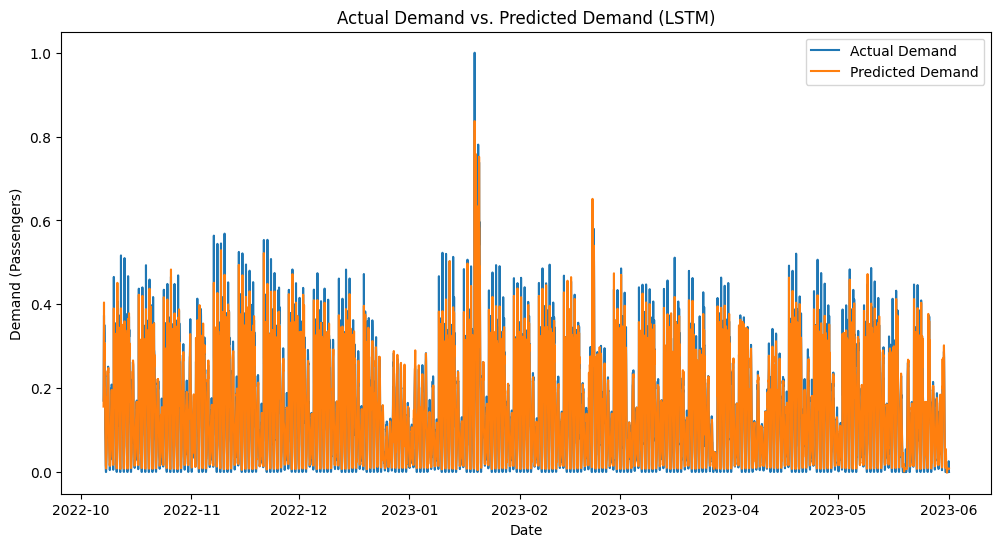

In [8]:
model.VisualizeActualVsPredicted("Actual Demand vs. Predicted Demand (LSTM)")

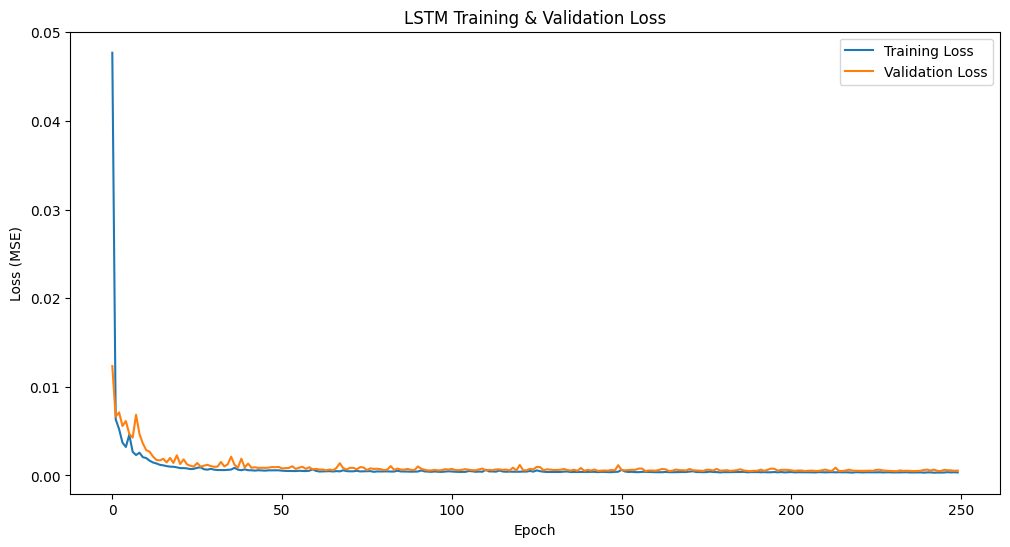

In [9]:
model.VisualizeLoss("LSTM Training & Validation Loss")

In [10]:
model.WritePredsToCSV()

In [11]:
model.PrintMetrics()

RMSE: 0.16166724792587941
MAE: 0.015345865421705171
R^2 Score: 0.9622794861422426
